# Beyond BLAST

In [2]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [3]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/new_funcs.jl");

In [4]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using .Blast
using .blast_tutorials;

### Computing background quantities:

redshift $z$, comoving distance $\chi(z)$

In [418]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
χ_b = npzread("blast_code/data/background/chi.npy") # array 
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
χ_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)
println("Redshift range of z_b: ", minimum(z_b), " ", maximum(z_b), "; dimension: ", size(z_b)[1])
println("Comoving distance range x_b: ", minimum(χ_b), " ", maximum(χ_b), "; dimension: ", size(χ_b)[1])
println("Redshift range of interpolated z_of_χ: ", minimum(z_of_χ(χ_b)), " ", maximum(z_of_χ(χ_b)), "; dimension: ", size(z_of_χ(χ_b))[1])
println("Comoving distance range of interpolated χ_of_z: ", minimum(χ_of_z(z_b)), " ", maximum(χ_of_z(z_b)), "; dimension: ", size(χ_of_z(z_b))[1])
println("The quantity z_b and x_b are the same as z_of_χ.(χ_b) and χ_of_z.(z_b) respectively, up to numerical precision.")

Redshift range of z_b: 0.0 100.0; dimension: 1024
Comoving distance range x_b: 0.0 12830.219503765933; dimension: 1024
Redshift range of interpolated z_of_χ: 0.0 100.0; dimension: 1024
Comoving distance range of interpolated χ_of_z: 0.0 12830.219503765933; dimension: 1024
The quantity z_b and x_b are the same as z_of_χ.(χ_b) and χ_of_z.(z_b) respectively, up to numerical precision.


In [419]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
println("N5K bins: ", keys(n5k_bins))
println("size of N5K dN/dz (clustering): ")
println(size(n5k_bins["dNdz_cl"]))
println("There are ", size(n5k_bins["z_cl"])[1], " redshift values for each of the ", size(n5k_bins["dNdz_cl"])[2], " bins.")
println("---")
println("first and last value of N5K dNdz (clustering): ")
println(minimum(n5k_bins["dNdz_cl"]), " ", maximum(n5k_bins["dNdz_cl"]))
println("first and last value of N5K z (clustering): ")
println(minimum(n5k_bins["z_cl"]), " ", maximum(n5k_bins["z_cl"]))

N5K bins: ["dNdz_cl", "z_sh", "dNdz_sh", "z_cl"]
size of N5K dN/dz (clustering): 
(2000, 10)
There are 2000 redshift values for each of the 10 bins.
---
first and last value of N5K dNdz (clustering): 
0.0 5.137721324028306
first and last value of N5K z (clustering): 
0.005833332 3.494166


In [429]:
# array of redshift values and dN/dz values for the N5K clustering sample
z_n5k = vec(n5k_bins["z_cl"])
z_n5k = sort(z_n5k) # sort the redshift array in ascending order
println("Range of N5K z (clustering): ", minimum(z_n5k), " ", maximum(z_n5k), "; dimension: ", size(z_n5k)[1])
n_z_matrix = n5k_bins["dNdz_cl"]
println("Range of N5K dN/dz (clustering): ", minimum(n_z_matrix), " ", maximum(n_z_matrix), "; dimension: ", size(n_z_matrix))

Range of N5K z (clustering): 0.005833332 3.494166; dimension: 2000
Range of N5K dN/dz (clustering): 0.0 5.137721324028306; dimension: (2000, 10)


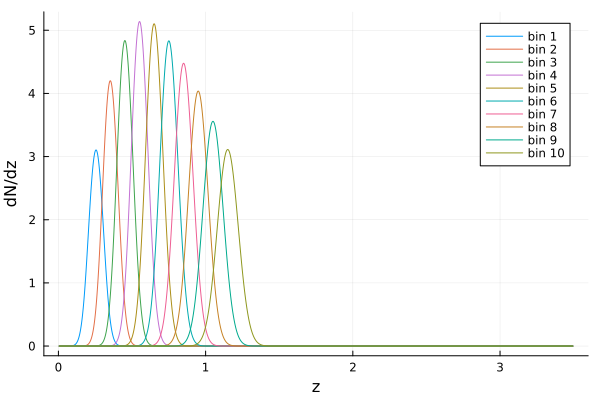

In [430]:
p = plot()
for i in 1:size(n_z_matrix, 2)
    plot!(p, z_cl, n_z_matrix[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
display(p)

### Normalizing the n(z)

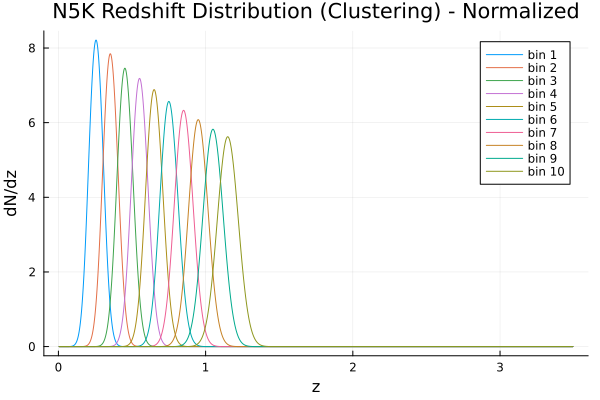

In [436]:
norms = [quadgk(x -> DataInterpolations.AkimaInterpolation(n_z_matrix[:, i], z_n5k, extrapolation=ExtrapolationType.Linear)(x),
                minimum(z_n5k), maximum(z_n5k))[1] for i in 1:size(n_z_matrix, 2)]
n_z_norm = n_z_matrix ./ reshape(norms, 1, :);
#### PLOTTING the results
p = plot()
for i in 1:size(n_z_norm, 2)
    plot!(p, z_n5k, n_z_norm[:, i], label="bin $i")
end
xlabel!(p, "z")
ylabel!(p, "dN/dz")
title!(p, "N5K Redshift Distribution (Clustering) - Normalized")
display(p)

In [439]:
#### REDSHIFT ARRAY
z_array = LinRange(minimum(z_n5k), maximum(z_n5k), size(z_n5k)[1]) # array of redshifts to evaluate n(z) on
#z_array = sort(z_array) # sort the redshift array in ascending order
println("z_array is a vector or dimension: ", size(z_array)[1])
println("Redshift range of z_array: ", minimum(z_array), " ", maximum(z_array))
println("-------")
#println(z_array - z_n5k) # check that z_array and z_n5k are the same
#### COMOVING DISTANCES ARRAY
chi_array = χ_of_z.(z_array) # array of comoving distances corresponding to z_range
println("chi_array is a vector or dimension: ", size(chi_array)[1])
println("Comoving distance range of chi_array: ", minimum(chi_array), " ", maximum(chi_array))
println("-------")
#### NORMALIZED n(z) FOR EACH BIN
println("nz_norm is a vector or dimension: ", size(n_z_norm)[1])
println("-------")
println("Normalized n(z) for each bin: ")
println("Range of normalized N5K dN/dz (clustering): ", minimum(n_z_norm), " ", maximum(n_z_norm), "; dimension: ", size(n_z_norm))
println("Values of normalized N5K dN/dz (clustering) for the first bin: ")
println(n_z_norm[:, 1]) # print the normalized dN/dz values for the first bin
println("-------")

z_array is a vector or dimension: 2000
Redshift range of z_array: 0.005833332 3.494166
-------
chi_array is a vector or dimension: 2000
Comoving distance range of chi_array: 25.97289945692804 6955.741691137702
-------
nz_norm is a vector or dimension: 2000
-------
Normalized n(z) for each bin: 
Range of normalized N5K dN/dz (clustering): 0.0 8.212653984189798; dimension: (2000, 10)
Values of normalized N5K dN/dz (clustering) for the first bin: 
[2.517879167649696e-7, 3.2958818872645264e-7, 4.304517286425635e-7, 5.609108316169329e-7, 7.29256409328066e-7, 9.45985012726896e-7, 1.224352175758934e-6, 1.5810554389260456e-6, 2.0370750589631195e-6, 2.6187058674580875e-6, 3.358820121521765e-6, 4.298408618739959e-6, 5.488455961888523e-6, 6.992215800966303e-6, 8.887963303939453e-6, 1.1272315172613029e-5, 1.426422238974121e-5, 1.8009757722249623e-5, 2.268783897453867e-5, 2.8517050238425824e-5, 3.5763747061387405e-5, 4.47516576700897e-5, 5.587322122980492e-5, 6.960293564100155e-5, 8.651302157089884

0.09735395279476108, 0.11045896314565873, 0.1250679146154669, 0.14131596084357553, 0.1593454827010732, 0.17930586224892603, 0.2013531656398738, 0.22564972907874398, 0.2523636427207789, 0.28166812831370547, 0.31374080747480665, 0.3487628587334756, 0.38691806285320596, 0.4283917374611519, 0.4733695636406733, 0.5220363088610641, 0.5745744524035918, 0.6311627212650132, 0.6919745463469144, 0.7571764505369376, 0.8269263820196061, 0.9013720077824031, 0.9806489837689907, 1.0648792194384131, 1.1541691555809894, 1.2486080750849382, 1.348266466912597, 1.4531944638059544, 1.5634203741779784, 1.678949328244641, 1.7997620577054319, 1.9258138271874896, 2.057033534237716, 2.193322992893936, 2.3345564138134764, 2.4805800916160226, 2.6312123075451423, 2.7862434528134052, 2.9454363751192942, 3.1085269478639193, 3.275224858609302, 3.445214610366779, 3.618156726443332, 3.7936891468640215, 3.9714288018861645, 4.1509733458773495, 4.331903032891428, 4.513782713684405, 4.696163932697451, 4.878587102720809, 5.0

In [441]:
println("Minimum and maximum values of nz_norm: ", minimum(n_z_norm), " ", maximum(n_z_norm))
println("Dimension of nz_norm: ", size(n_z_norm)[1])
println("Shape of N5K dN/dz (clustering): ", size(n_z_norm))
println("Redshift range of N5K dN/dz (clustering): ", minimum(n_z_norm), " ", maximum(n_z_norm), "; dimension: ", size(n_z_norm))

Minimum and maximum values of nz_norm: 0.0 8.212653984189798
Dimension of nz_norm: 2000
Shape of N5K dN/dz (clustering): (2000, 10)
Redshift range of N5K dN/dz (clustering): 0.0 8.212653984189798; dimension: (2000, 10)


In [442]:
println("minimum and maximum values of z_array: ", minimum(z_array), " ", maximum(z_array))
println("minimum and maximum values of z_range: ", minimum(z_range), " ", maximum(z_range))
println("dimension of z_array: ", size(z_array)[1])
println("dimension of z_range: ", size(z_range)[1])

minimum and maximum values of z_array: 0.005833332 3.494166
minimum and maximum values of z_range: 0.005829802271562456 3.5484647664654276
dimension of z_array: 2000
dimension of z_range: 96


In [450]:
cosmo = Blast.FlatΛCDM()
nχ = 96                     # Number of comoving distance points
# Array of comoving distances
x_array = LinRange(26, 7000, nχ)
# Array of redshifts corresponding to the comoving distances
z_range = z_of_χ.(x_array)
println("First and last values of z_range: ", first(z_range), " ", last(z_range))
###### BIAS ######
# compute the bias. the equation is b(z) = b_0 * sqrt(1+z). we set b_0 = 1.0.!
b_0 = 1.0
b_z_array = b_0 .* sqrt.(1 .+ z_range) # bias as a function of redshift
###### GROWTH FACTOR ######
#i want to obtain the growth factor D(z) from the background quantities. i can use the cosmology package to compute this.
function heath_integral(cosmo, z)
    integrand(zp) = (1.0 + zp) / (Blast.compute_adimensional_hubble_factor(zp, cosmo)^3)
    integral_val, _ = quadgk(integrand, z, Inf, rtol=1e-8)
    return Blast.compute_adimensional_hubble_factor(z, cosmo) * integral_val
end
function compute_growth_factor(cosmo, z_range)
    D_unnorm_z0 = heath_integral(cosmo, 0.0)
    D_array = [heath_integral(cosmo, zz) / D_unnorm_z0 for zz in z_range]
    return D_array
end
# Array of growth factor values
growth_array = compute_growth_factor(cosmo, z_range)
println("First and last values of growth_array: ", first(growth_array), " ", last(growth_array))
###############################

First and last values of z_range: 0.005829802271562456 3.5484647664654276
First and last values of growth_array: 0.996927139848262 0.2777909609205806


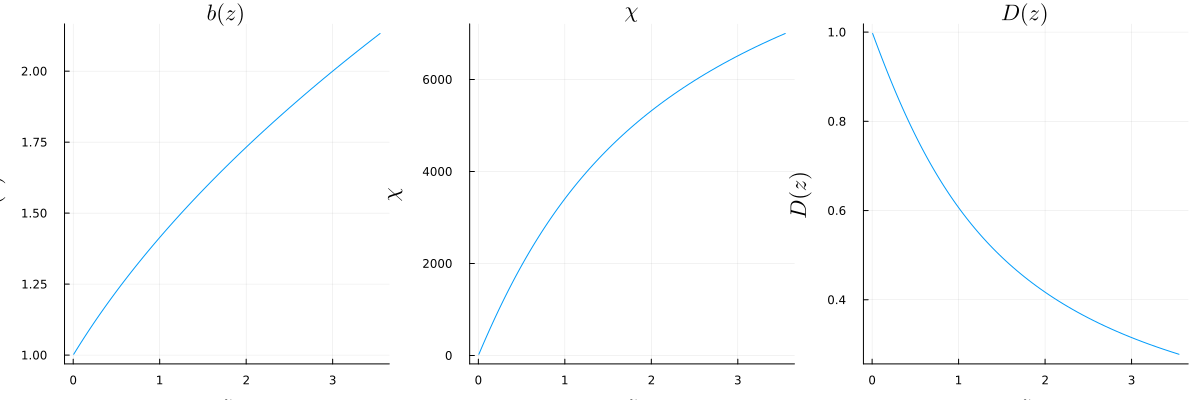

print device already activated


In [453]:
p1 = plot(z_range, 
          b_z_array, 
          label=L"$b(z)$", 
          xlabel=L"$z$", 
          ylabel=L"$b(z)$", 
          title=L"$b(z)$")
p2 = plot(z_range, 
          x_array, 
          label=L"z and $\chi$",
          title = L"$\chi$",
          xlabel=L"$z$", 
          ylabel=L"$\chi$")
p3 = plot(z_range, 
          growth_array, 
          label="Growth Factor D(z)", 
          xlabel=L"$z$", 
          ylabel=L"$D(z)$", 
          title=L"$D(z)$")
plot(p1, p2, p3, layout=(1,3), titlefontsize=15, labelfontsize=15, legendfontsize=15, size=(1200,400), legend=false)


In [455]:
println("First and last values of z_range: ", first(z_range), " ", last(z_range))
println("Dimension of z_range: ", size(z_range)[1])
println("First and last values of z_array: ", first(z_array), " ", last(z_array))

First and last values of z_range: 0.005829802271562456 3.5484647664654276
Dimension of z_range: 96
First and last values of z_array: 0.005833332 3.494166


Number of tomographic bins: 10
(96, 10)
Dimension of kernel_composed: 96
Dimension of z_range: 96
Size of array: chi(z): 2000
Size of array: b(z): 96
Size of array: D(z): 96
Size of array: n(z): (2000, 10)


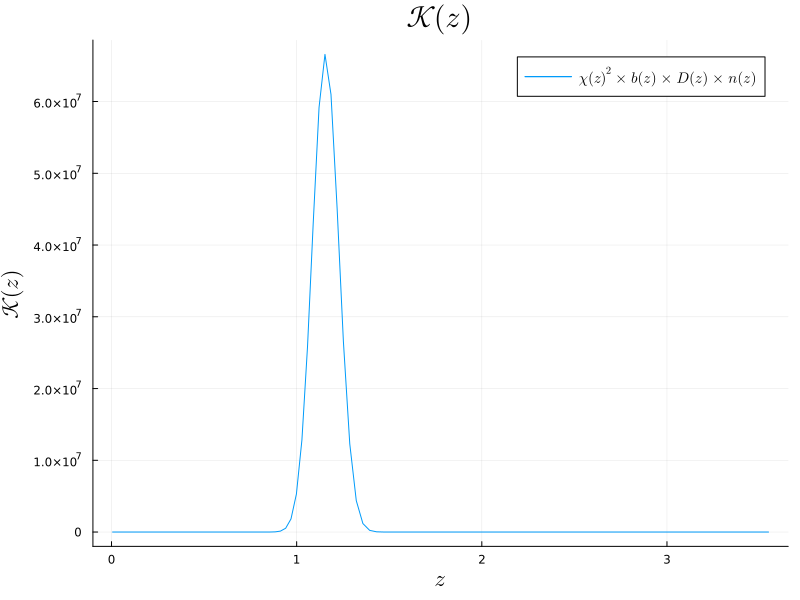

In [ ]:
n_bins = size(n_z_norm, 2) # number of tomographic bins
nz = zeros(size(z_range, 1), n_bins) # size nx per number of bins
println("Number of tomographic bins: ", n_bins)
for b in 1:n_bins
     nz_func = DataInterpolations.AkimaInterpolation(n_z_norm[:, b], z_array, extrapolation=ExtrapolationType.Linear)
     nz_norm, _ = quadgk(nz_func, minimum(z_range), maximum(z_range), rtol=1e-8)
     #println("Bin $b: Normalized n(z) integral: ", nz_norm)
     nz[:, b] = nz_func.(z_range)/nz_norm
     #println("Bin $b: n(z) has size: ", size(nz))
end
println(size(nz))

for b in 1:n_bins
     kernel_composed = x_array.^2 .* b_z_array .* growth_array .* nz[:, b] # for each bin
end

########### CONTINUE HERE ###########
println("Dimension of kernel_composed: ", size(kernel_composed)[1])
println("Dimension of z_range: ", size(z_range)[1])
# here i compute the quantity that multiplies the comoving distance, the bias factor, the growth factor, the density n(z)
println("Size of array: chi(z): ", size(chi_array)[1])
println("Size of array: b(z): ", size(b_z_array)[1])
println("Size of array: D(z): ", size(growth_array)[1])
println("Size of array: n(z): ", size(n_z_norm))
plot(z_range, kernel_composed, 
     label=L"$ \chi(z)^2 \times b(z) \times D(z) \times n(z)$", 
     xlabel=L"$z$", 
     ylabel=L"\mathcal{K}(z)", 
     title=L"\mathcal{K}(z)",
     labelfont=20,
     labelcolor=:blue,
     titlefontsize=20, 
     xlabelfontsize=15,
     ylabelfontsize=15,
     legendfontsize=10,
     size=(800,600))

In [382]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

In [383]:
println("Dimension of k points: ", size(k)[1])
println("Dimension of Pklin: ", size(Pklin)[1])
println("Dimension of Pknonlin: ", size(Pknonlin)[1])

Dimension of k points: 200
Dimension of Pklin: 50
Dimension of Pknonlin: 50


In [384]:
#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

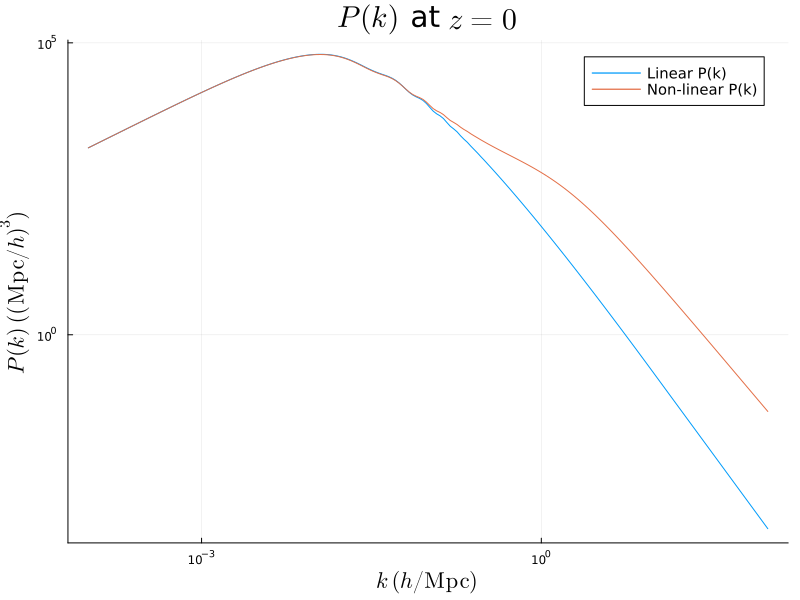

In [385]:
plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10,
      size=(800,600),
      legendfontsize=10)

In [386]:
#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
ll_reshaped = zeros(dtype, length(ell), 5, 5)
gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1
for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

In [387]:
ℓ = Blast.ℓ
n_chi = 96                                            # number of comoving "bins"
x_min = 26                                            # minimum comoving distance
x_max = 7000                                          # maximum comoving distance
χ = LinRange(x_min, x_max, n_chi)                     # array of comoving distances
R = chebpoints(n_chi, -1, 1)                          # array of ratios between comoving distances
R = reverse(R[R.>0])
nR = length(R)                                        # number of ratios R
kmax = 200/13                                         # maximum wavenumber (small scales)
kmin = 2.5/x_max                                      # minimum wavenumber (large scales)
n_cheb = 119                                          # number of Chebyshev nodes 
β = 2                                                 # exponent depending on the probe: 0 for Galaxy - Shear, 2 for Galaxy - Galaxy, -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
N = 2^(15)+1;                                         # number of integration points


# Define k' and k'' on Chebyshev grid
#k1 = k2 = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax)) # wavenumbers k' and k''

In [388]:
# I choose a grid of Chebyshev nodes in z, which I will use to evaluate 
# the kernels and the power spectrum.
zmin = first(z_range)
zmax = last(z_range)
println("Minimum and maximum values of z_range: ", zmin, " ", zmax)

t_of_z(z) = (2*z - (zmax + zmin)) / (zmax - zmin)
z_of_t(t) = (zmin + zmax)/2 + (zmax - zmin)/2 * t

j = 1:n_cheb
t_nodes = cos.((2 .* j .- 1) .* pi ./ (2*n_cheb))     # size N, in [-1,1]
z_nodes = z_of_t.(t_nodes)                            # Chebyshev nodes in z

println("First Chebyshev node in z: ", z_nodes[1])
println("Last Chebyshev node in z: ", z_nodes[end])
println("-------")
println("First Chebyshev node in t: ", t_nodes[1])
println("Last Chebyshev node in t: ", t_nodes[end])

Minimum and maximum values of z_range: 0.005829802271562456 3.5484647664654276
First Chebyshev node in z: 3.5483104522487574
Last Chebyshev node in z: 0.005984116488232383
-------
First Chebyshev node in t: 0.9999128816724107
Last Chebyshev node in t: -0.9999128816724107


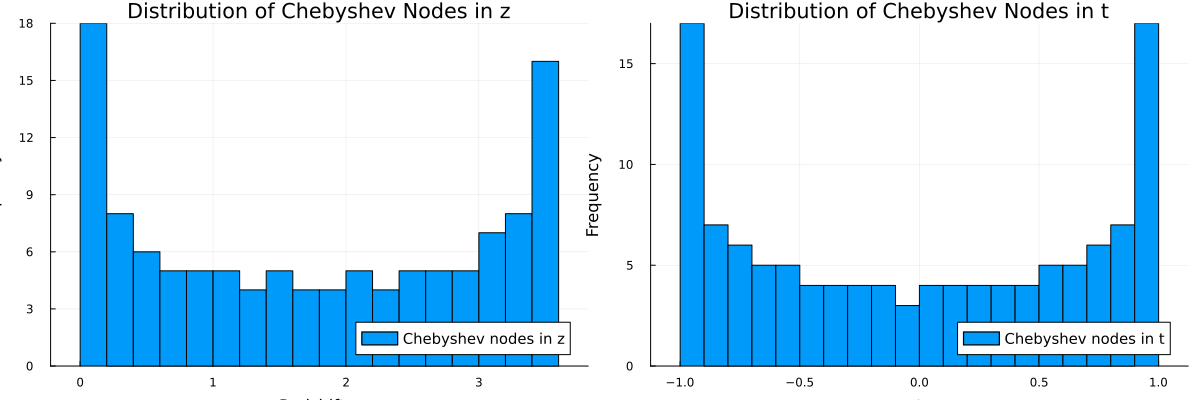

In [389]:
h1 = histogram(z_nodes, bins=20, 
               label="Chebyshev nodes in z", 
               xlabel="Redshift z", 
               ylabel="Frequency", 
               title="Distribution of Chebyshev Nodes in z",
               legendfontsize=10,
               legend=:bottomright)
h2 = histogram(t_nodes, bins=20, 
               label="Chebyshev nodes in t", 
               xlabel="t", 
               ylabel="Frequency", 
               title="Distribution of Chebyshev Nodes in t",
               legendfontsize=10,
               legend=:bottomright)
plot(h1, h2, layout=(1,2), size=(1200,400))

In [390]:
# build simple interpolants for b, D, n defined on z_array
b_interp = extrapolate(interpolate((z_array,), b_z_array, Gridded(Linear())), Line())
D_interp = extrapolate(interpolate((z_array,), growth_array, Gridded(Linear())), Line())
n_interp = extrapolate(interpolate((z_array,), n_z_array, Gridded(Linear())), Line())
#n_interp = extrapolate(interpolate((z_array,), nz_norm, Gridded(Linear())), Line())
println("Max of n_interp: ", maximum(n_interp))
println("Min of n_interp: ", minimum(n_interp))
# evaluate χ at Chebyshev z_nodes (χ_of_z from your Akima interp)
χ_nodes = χ_of_z.(z_nodes)
println("First and last values of χ_nodes: ", first(χ_nodes), " ", last(χ_nodes))
println("Dimension of χ_nodes: ", size(χ_nodes)[1])
println("Dimension of z_nodes: ", size(z_nodes)[1])
# combined kernel at nodes
K_nodes = χ_nodes .^ 2 .* b_interp.(z_nodes) .* D_interp.(z_nodes) .* n_interp.(z_nodes)
planK = Blast.plan_fft(K_nodes)
K_cheb_coeff = Blast.fast_chebcoefs(K_nodes, planK)
println("Chebyshev coefficients: ", K_cheb_coeff)
println("Max of K_cheb_coeff: ", maximum(K_cheb_coeff))
println("Min of K_cheb_coeff: ", minimum(K_cheb_coeff))

LoadError: DimensionMismatch: knot vectors must have the same axes as the corresponding dimension of the array

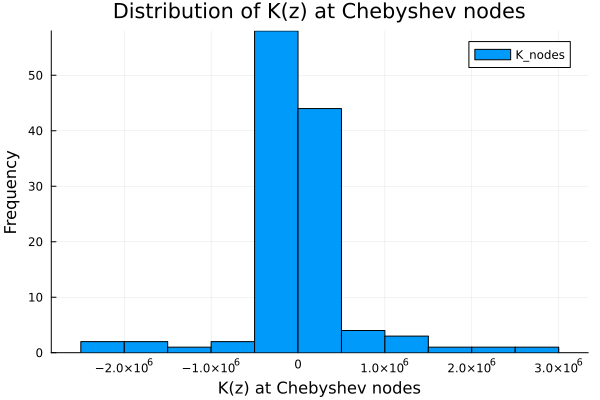

In [391]:
histogram(K_cheb_coeff, bins=20, label="K_nodes", xlabel="K(z) at Chebyshev nodes", ylabel="Frequency", title="Distribution of K(z) at Chebyshev nodes")

In [124]:
println("Dimension of b_interpolant: ", size(b_interp)[1])
println("First value of b_interpolant at nodes: ", b_interp.(z_nodes)[1])
println("Last value of b_interpolant at nodes: ", b_interp.(z_nodes)[end])
println("-----")
println("Dimension of D_interpolant: ", size(D_interp)[1])
println("First value of D_interpolant at nodes: ", D_interp.(z_nodes)[1])
println("Last value of D_interpolant at nodes: ", D_interp.(z_nodes)[end])
println("-----")
println("Dimension of n_interpolant: ", size(n_interp)[1])
println("First value of n_interpolant at nodes: ", n_interp.(z_nodes)[1])
println("Last value of n_interpolant at nodes: ", n_interp.(z_nodes)[end])
println("-----")
println("Dimension of z_nodes: ", size(z_nodes)[1])
println("First value of z_nodes: ", z_nodes[1])
println("Last value of z_nodes: ", z_nodes[end])
println("-----")
println("Dimension of χ_nodes: ", size(χ_nodes)[1])
println("First value of χ_nodes: ", χ_nodes[1])
println("Last value of χ_nodes: ", χ_nodes[end])
println("-----")
println("Dimension of K_nodes: ", size(K_nodes)[1])
println("First value of K_nodes: ", K_nodes[1])
println("Last value of K_nodes: ", K_nodes[end])
println("-----")
println("Dimension of Chebyshev coefficients: ", size(K_cheb_coeff)[1])
println("First value of Chebyshev coefficients: ", K_cheb_coeff[1])
println("Last value of Chebyshev coefficients: ", K_cheb_coeff[end])
println("-----")

Dimension of b_interpolant: 20000
First value of b_interpolant at nodes: 2.1326767525024213
Last value of b_interpolant at nodes: 1.0029871065696088
-----
Dimension of D_interpolant: 20000
First value of D_interpolant at nodes: 0.2778003450102349
Last value of D_interpolant at nodes: 0.9968462885109431
-----
Dimension of n_interpolant: 20000
First value of n_interpolant at nodes: 1.354587643679107e-128
Last value of n_interpolant at nodes: 1.3210273210426714e-7
-----
Dimension of z_nodes: 119
First value of z_nodes: 3.5483104522487574
Last value of z_nodes: 0.005984116488232383
-----
Dimension of χ_nodes: 119
First value of χ_nodes: 6999.870114443534
Last value of χ_nodes: 26.643271327792124
-----
Dimension of K_nodes: 119
First value of K_nodes: 3.932284111705816e-121
Last value of K_nodes: 9.375845476868986e-5
-----
Dimension of Chebyshev coefficients: 119
First value of Chebyshev coefficients: 1.5356658304733124e6
Last value of Chebyshev coefficients: -15.317806898158485
-----


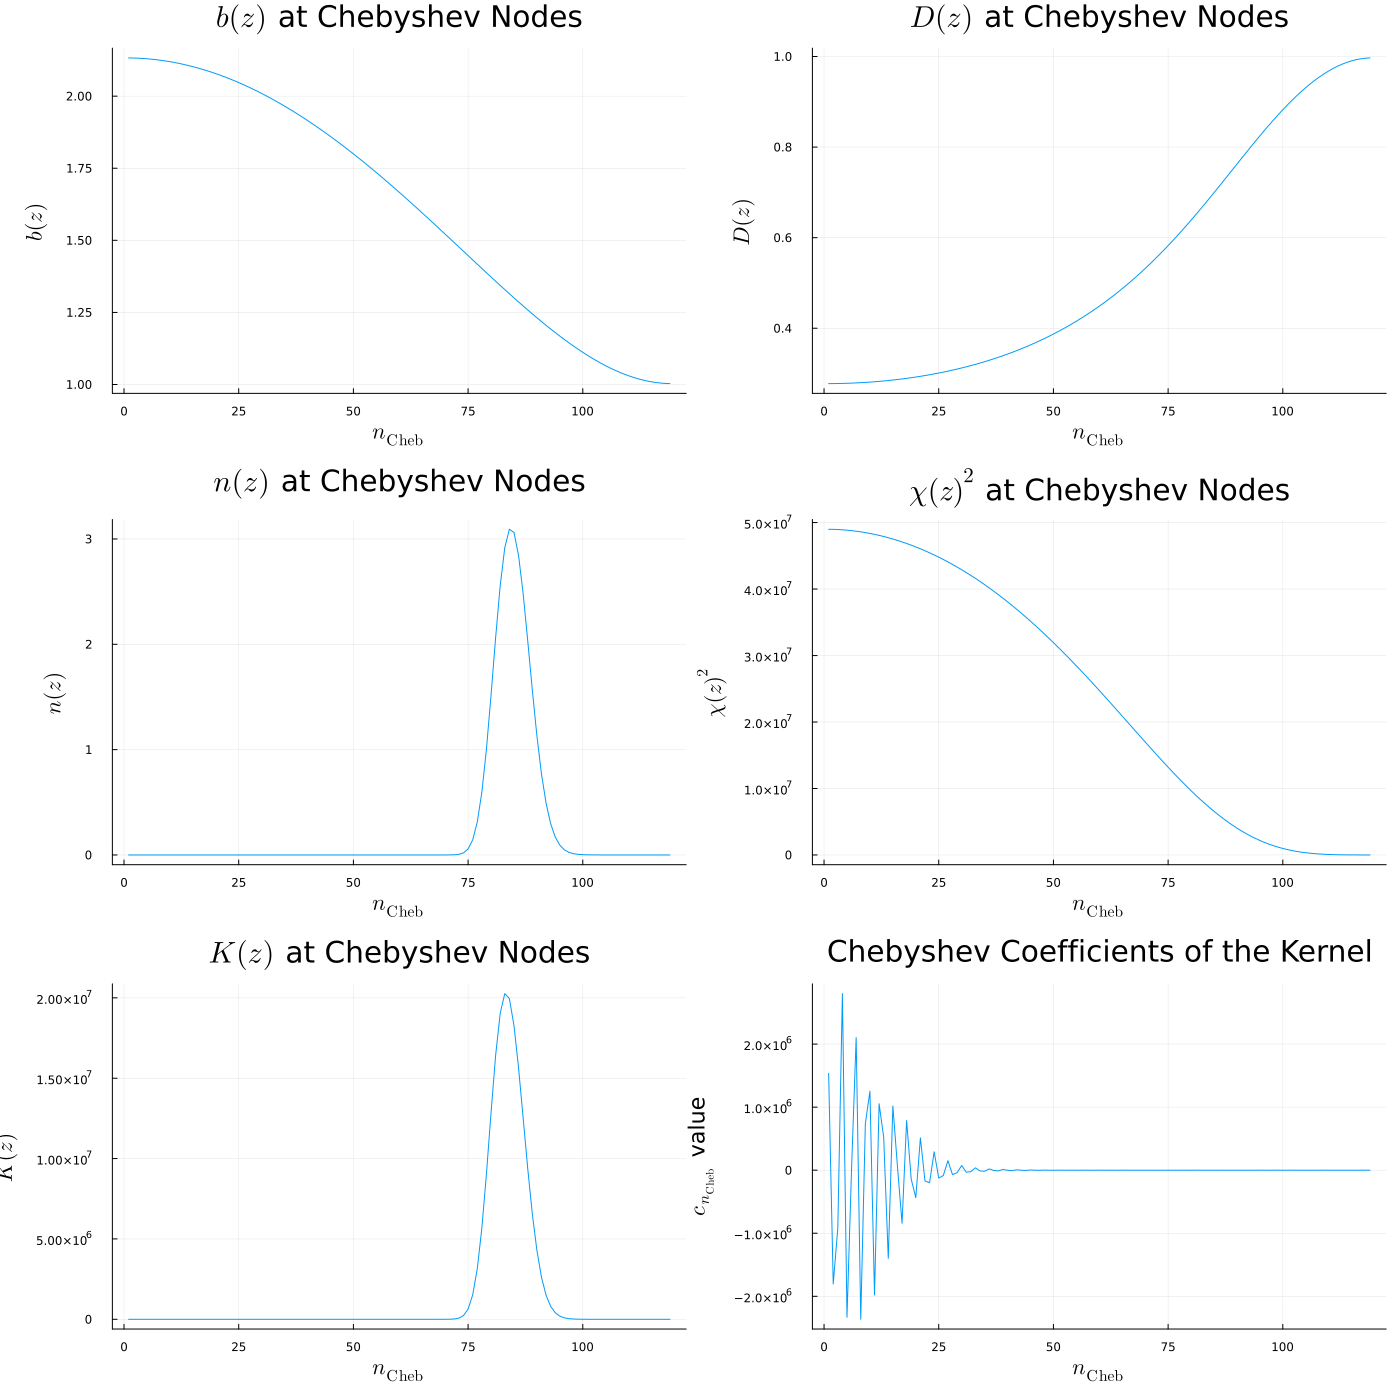

In [125]:
#create a plot of 6 plots: b_interp, D_interp, n_interp, χ_nodes^2, K_nodes, and the Chebyshev coefficients c, all evaluated at the Chebyshev nodes z_nodes.
p1 = plot(1:length(K_cheb_coeff), b_interp.(z_nodes),
    label="b_interp at nodes",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$b(z)$",
    title=L"$b(z)$ at Chebyshev Nodes"
    )
p2 = plot(1:length(K_cheb_coeff), D_interp.(z_nodes),
    label="D_interp at nodes",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$D(z)$",
    title=L"$D(z)$ at Chebyshev Nodes"
    )
p3 = plot(1:length(K_cheb_coeff), n_interp.(z_nodes),
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$n(z)$",
    title=L"$n(z)$ at Chebyshev Nodes"
    )
p4 = plot(1:length(K_cheb_coeff), χ_nodes .^ 2,
    label="χ_nodes^2",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$\chi(z)^2$",
    title=L"$\chi(z)^2$ at Chebyshev Nodes"
    )
p5 = plot(1:length(K_cheb_coeff), K_nodes,
    label="K_nodes",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$K(z)$",
    title=L"$K(z)$ at Chebyshev Nodes"
    )
p6 = plot(1:length(K_cheb_coeff), K_cheb_coeff,
    label="Chebyshev coefficients",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$c_{n_{\mathrm{Cheb}}}$ value",
    title="Chebyshev Coefficients of the Kernel",
    )

plot(p1, p2, p3, p4, p5, p6, layout=(3,2), size=(1400,1400), legend=false, labelfont=15, titlefontsize=20, xlabelfontsize=15, ylabelfontsize=15)


In [ ]:
# the same for the new kernel
# build simple interpolants for b, D, n defined on z_array
b_interp = extrapolate(interpolate((z_array,), b_z_array, Gridded(Linear())), Line())
D_interp = extrapolate(interpolate((z_array,), growth_array, Gridded(Linear())), Line())
n_interp = extrapolate(interpolate((z_array,), n_z_array, Gridded(Linear())), Line())
#n_interp = extrapolate(interpolate((z_array,), nz_norm, Gridded(Linear())), Line())
println("Max of n_interp: ", maximum(n_interp))
println("Min of n_interp: ", minimum(n_interp))
# evaluate χ at Chebyshev z_nodes (χ_of_z from your Akima interp)
χ_nodes = χ_of_z.(z_nodes)
H_nodes = Blast.compute_adimensional_hubble_factor.(z_nodes, Ref(cosmo))
println("First and last values of χ_nodes: ", first(χ_nodes), " ", last(χ_nodes))
println("Dimension of χ_nodes: ", size(χ_nodes)[1])
println("Dimension of z_nodes: ", size(z_nodes)[1])
# modified kernel  K~(z) = χ(z)^2 b(z) D(z) n(z) / H(z)
K_nodes_mod = χ_nodes .^ 2 .* b_interp.(z_nodes) .* D_interp.(z_nodes) .* n_interp.(z_nodes) ./ H_nodes
planK = Blast.plan_fft(K_nodes_mod)
K_cheb_coeff_mod = Blast.fast_chebcoefs(K_nodes_mod, planK)
println("Chebyshev coefficients: ", K_cheb_coeff_mod)
println("Max of K_cheb_coeff: ", maximum(K_cheb_coeff_mod))
println("Min of K_cheb_coeff: ", minimum(K_cheb_coeff_mod))

Max of n_interp: 4.196356200943078
Min of n_interp: -5.9770557571124196e-257
First and last values of χ_nodes: 6999.870114443534 26.643271327792124
Dimension of χ_nodes: 119
Dimension of z_nodes: 119
Chebyshev coefficients: [1.0035848510568872e6, -1.1913388485802268e6, -570452.3932742393, 1.8151607515992937e6, -1.555468207097345e6, 87915.01149001748, 1.3245814161336932e6, -1.5646794489433826e6, 566367.5214778986, 736247.0237961846, -1.2830027166341206e6, 761963.0982977076, 246089.54126300407, -873997.8939073388, 711184.2741913806, -47476.469853875526, -495862.7399832536, 529961.6412055026, -155540.35335261122, -232455.60235029968, 331707.1228737456, -149000.89593997566, -89206.51539005965, 180123.94577945294, -100503.87878830254, -29303.01587112995, 88285.03673504706, -54059.12104475559, -11329.39815594288, 41776.13999414082, -24383.875956165855, -7932.836952252402, 20958.00475199944, -9752.7612049713, -6987.123512815252, 11789.898820861785, -3904.398350186473, -5442.58456044579, 7146.

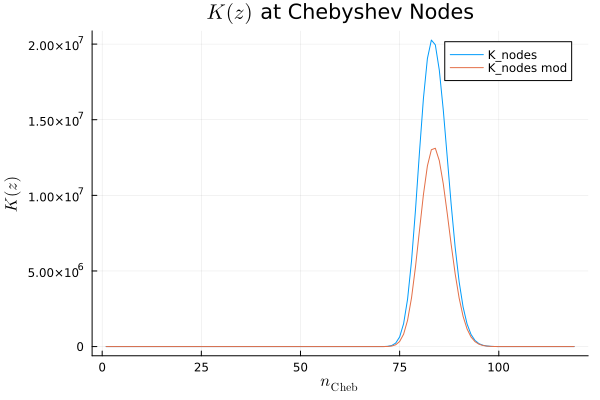

In [ ]:
plot(1:length(K_cheb_coeff), K_nodes,
    label="K_nodes",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$K(z)$",
    title=L"$K(z)$ at Chebyshev Nodes"
    )
plot!(1:length(K_cheb_coeff_mod), K_nodes_mod,
    label="K_nodes mod",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$K(z)$",
    title=L"$K(z)$ at Chebyshev Nodes"
    )

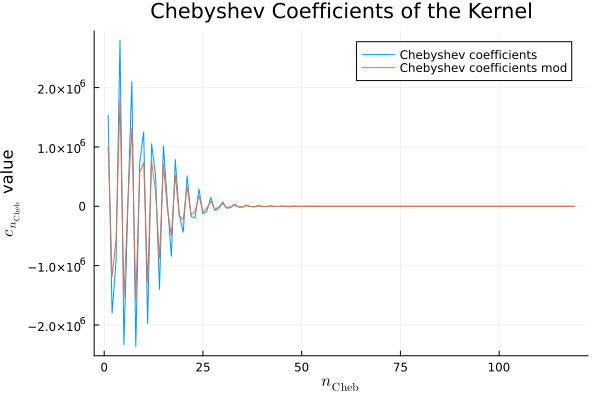

In [166]:
plot(1:length(K_cheb_coeff), K_cheb_coeff,
    label="Chebyshev coefficients",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$c_{n_{\mathrm{Cheb}}}$ value",
    title="Chebyshev Coefficients of the Kernel",
    )
plot!(1:length(K_cheb_coeff_mod), K_cheb_coeff_mod,
    label="Chebyshev coefficients mod",
    xlabel=L"$n_{\mathrm{Cheb}}$", ylabel=L"$c_{n_{\mathrm{Cheb}}}$ value",
    title="Chebyshev Coefficients of the Kernel",
    )

In [180]:
cosmo = Blast.FlatΛCDM()
z_range = z_of_χ.(χ)
bgrid = Blast.CosmologicalGrid(z_range = z_range)
bg = Blast.BackgroundQuantities(Hz_array = zeros(length(z_range)), χz_array = Array(χ));
GalKernels = Blast.GalaxyKernel(10, length(bgrid.z_range))
Blast.compute_kernel!(n5k_bins["dNdz_cl"]',  n5k_bins["z_cl"], GalKernels, bgrid, bg, cosmo)
W = npzread("blast_code/data/kernels_fullwidth.npz")
i_bin = 1
interp = DataInterpolations.AkimaInterpolation( W["kernels_cl"][i_bin,:], W["z_cl"], extrapolation = ExtrapolationType.Linear)
intn, _ = quadgk(x -> interp.(x), 0., 3.5)
interp = DataInterpolations.AkimaInterpolation( GalKernels.Kernel[i_bin,:], bgrid.z_range, extrapolation = ExtrapolationType.Linear)
intb, _ = quadgk(x -> interp.(x), 0., 3.5);

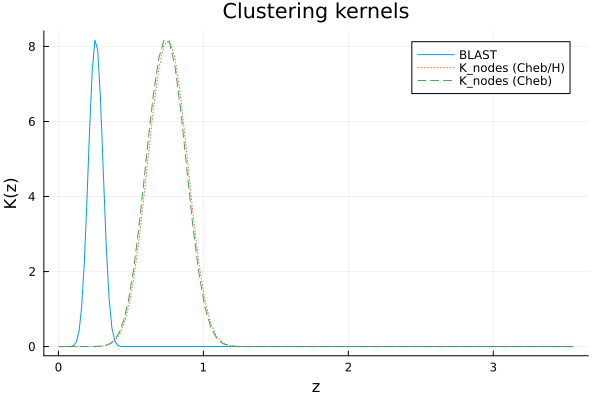

In [198]:
K_nodes_mod_norm = K_nodes_mod .* (maximum(GalKernels.Kernel[i_bin,:] ./ intb) / maximum(K_nodes_mod))
K_nodes_norm = K_nodes .* (maximum(GalKernels.Kernel[i_bin,:] ./ intb) / maximum(K_nodes))
plot(bgrid.z_range, GalKernels.Kernel[i_bin,:] ./ intb,
        label="BLAST", xlabel="z", ylabel="K(z)", title="Clustering kernels")
plot!(z_nodes, K_nodes_norm, label="K_nodes (Cheb/H)", linestyle=:dot)
plot!(z_nodes, K_nodes_mod_norm, label="K_nodes (Cheb)", linestyle=:dash)